In [18]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


# Modelagem Preditiva da Potabilidade da Água

Este notebook tem como objetivo construir, comparar e otimizar modelos de Machine Learning para prever a variável `potabilidade`.

A etapa de análise exploratória dos dados foi realizada em outro arquivo. Portanto, este notebook foca em:

- carregamento dos dados tratados;
- separação entre treino e teste;
- treinamento sem técnicas de reamostragem;
- treinamento de modelos de classificação;
- comparação de métricas;
- otimização de hiperparâmetros;
- avaliação final do melhor modelo;
- salvamento do modelo final.


In [19]:
# ============================================================
# 2. CARREGAMENTO DOS DADOS
# ============================================================

caminho_dados = "../data/02-processed/dados-agua-tratados.csv"

tabela = pd.read_csv(caminho_dados)

print("Dimensão da base:", tabela.shape)
tabela.head()

Dimensão da base: (2011, 10)


,pH,dureza,std,cloraminas,sulfato,condutividade,carbono_orgânico,trihalometano,turbidez,potabilidade
0,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
1,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
2,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
3,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
4,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


In [20]:
# ============================================================
# 3. SEPARAÇÃO ENTRE VARIÁVEIS EXPLICATIVAS E VARIÁVEL-ALVO
# ============================================================

X = tabela.drop("potabilidade", axis=1)
y = tabela["potabilidade"]

print("Variáveis explicativas:", X.shape)
print("Variável-alvo:", y.shape)

Variáveis explicativas: (2011, 9)
Variável-alvo: (2011,)


In [21]:
# ============================================================
# 4. DISTRIBUIÇÃO DA VARIÁVEL-ALVO
# ============================================================

distribuicao_alvo = y.value_counts(normalize=True).rename("proporcao")
distribuicao_alvo

potabilidade
0    0.596718
1    0.403282
Name: proporcao, dtype: float64

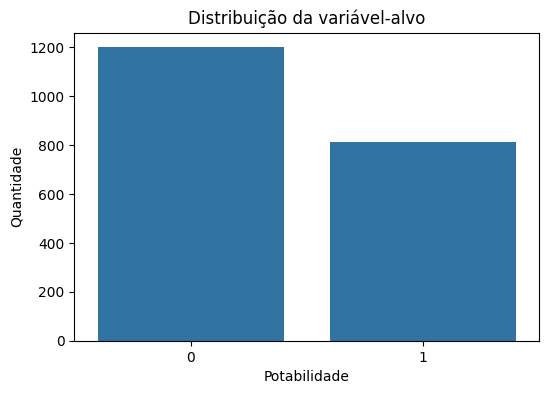

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribuição da variável-alvo")
plt.xlabel("Potabilidade")
plt.ylabel("Quantidade")
plt.show()

A variável-alvo apresenta um leve desbalanceamento entre as classes.
  
Nesta etapa, optou-se por realizar o treinamento dos modelos sem a aplicação de técnicas de balanceamento, como SMOTE ou SMOTETomek, mantendo a divisão estratificada entre os conjuntos de treino e teste a fim de preservar a distribuição original das classes no conjunto de dados.

In [23]:
# ============================================================
# 5. SEPARAÇÃO ENTRE TREINO E TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1608, 9)
X_test: (403, 9)
y_train: (1608,)
y_test: (403,)


A separação dos dados foi realizada utilizando o parâmetro `stratify=y`, garantindo a preservação da proporção original das classes nos conjuntos de treino e teste. Essa abordagem contribui para uma avaliação mais consistente e representativa do desempenho dos modelos em relação à distribuição real da variável-alvo.

In [24]:
# ============================================================
# 6. DEFINIÇÃO DOS MODELOS BASE
# ============================================================

modelos_base = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0
    ),
    
    "LightGBM": LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1,
        force_col_wise=True
    ),
    
    "CatBoost": CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0
    )
}

In [25]:
# ============================================================
# 7. FUNÇÃO DE AVALIAÇÃO DOS MODELOS
# ============================================================

def avaliar_modelo(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    """
    Treina um modelo sem SMOTE/SMOTETomek e retorna as principais métricas.
    """
    
    pipeline = Pipeline(steps=[
        ("modelo", modelo)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    if hasattr(pipeline.named_steps["modelo"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    resultados = {
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    }
    
    matriz_confusao = confusion_matrix(y_test, y_pred)
    
    return resultados, matriz_confusao, pipeline


In [26]:
# ============================================================
# 8. TREINAMENTO E COMPARAÇÃO DOS MODELOS BASE
# ============================================================

resultados_modelos = []
matrizes_confusao = {}
pipelines_treinados = {}

for nome, modelo in modelos_base.items():
    resultado, matriz, pipeline = avaliar_modelo(
        nome,
        modelo,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    resultados_modelos.append(resultado)
    matrizes_confusao[nome] = matriz
    pipelines_treinados[nome] = pipeline

resultados_df = pd.DataFrame(resultados_modelos)
resultados_df = resultados_df.sort_values(by="F1-score", ascending=False)

resultados_df

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC
4,CatBoost,0.717122,0.742574,0.460123,0.568182,0.732669
3,LightGBM,0.667494,0.610687,0.490798,0.544218,0.709305
0,Random Forest,0.702233,0.721649,0.429448,0.538462,0.738855
2,XGBoost,0.650124,0.583333,0.472393,0.522034,0.679346
1,Gradient Boosting,0.642680,0.633803,0.276074,0.384615,0.661810


A métrica ROC-AUC foi utilizada como principal critério de avaliação por medir a capacidade geral do modelo em distinguir corretamente as classes, independentemente do limiar de decisão adotado. Essa abordagem permite uma análise mais robusta do desempenho dos modelos em problemas de classificação binária.

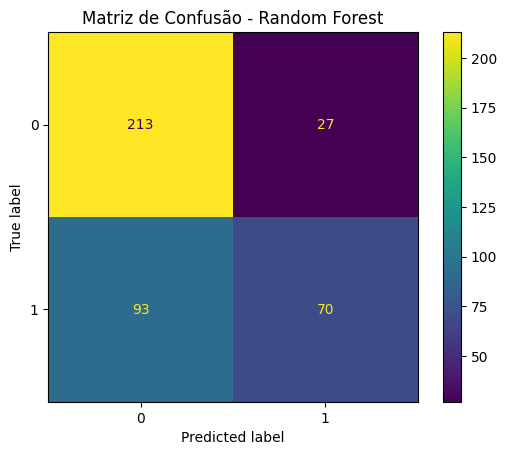

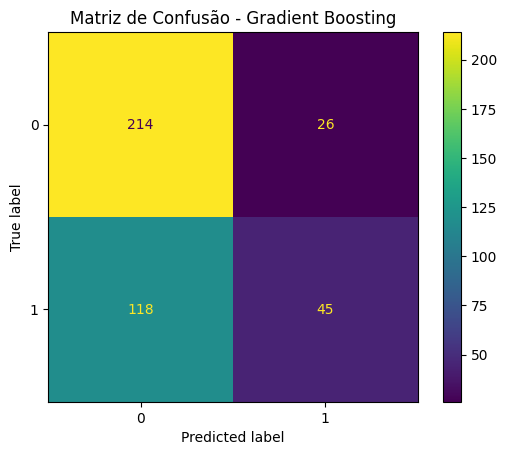

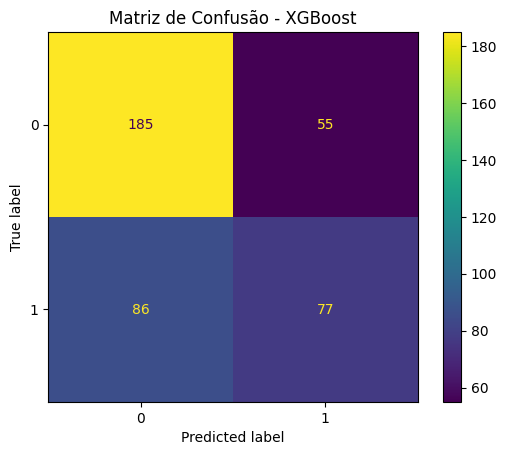

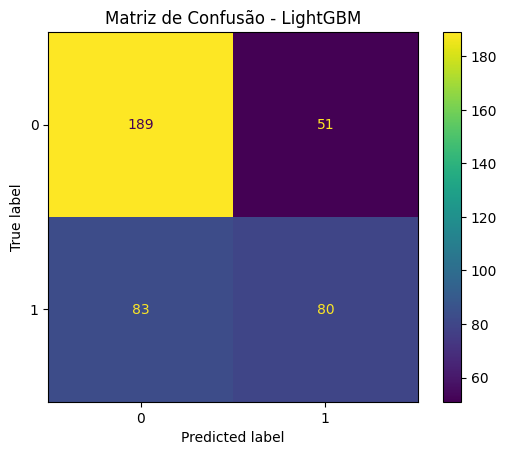

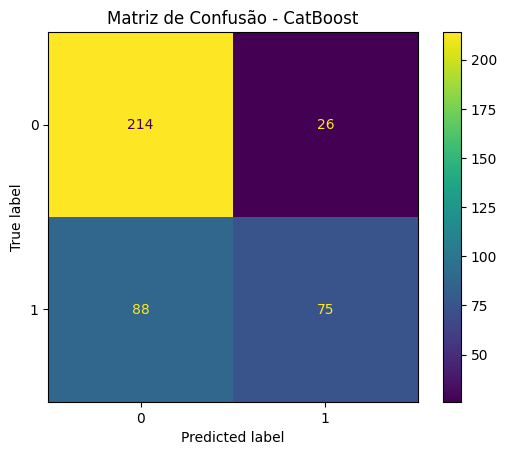

In [27]:
# ============================================================
# 9. MATRIZES DE CONFUSÃO DOS MODELOS BASE
# ============================================================

for nome, matriz in matrizes_confusao.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

In [28]:
# ============================================================
# 10. DEFINIÇÃO DOS HIPERPARÂMETROS PARA OTIMIZAÇÃO
# ============================================================

from scipy.stats import randint, uniform, loguniform

parametros_modelos = {
    "Random Forest": {
        "modelo": RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ),
        "params": {
            "modelo__n_estimators": randint(200, 801),
            "modelo__max_depth": [5, 10, 15, 20, None],
            "modelo__min_samples_split": randint(2, 11),
            "modelo__min_samples_leaf": randint(1, 6),
            "modelo__max_features": ["sqrt", "log2"]
        }
    },

    "XGBoost": {
        "modelo": XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            verbosity=0,
            tree_method="hist"
        ),
        "params": {
            "modelo__n_estimators": randint(200, 901),
            "modelo__max_depth": randint(3, 9),
            "modelo__learning_rate": loguniform(0.01, 0.2),
            "modelo__subsample": uniform(0.6, 0.4),
            "modelo__colsample_bytree": uniform(0.6, 0.4),
            "modelo__reg_lambda": loguniform(0.1, 10),
            "modelo__reg_alpha": loguniform(0.001, 1)
        }
    },

    "LightGBM": {
        "modelo": LGBMClassifier(
            random_state=RANDOM_STATE,
            verbose=-1,
            force_col_wise=True
        ),
        "params": {
            "modelo__n_estimators": randint(200, 901),
            "modelo__max_depth": [-1, 3, 5, 8, 10],
            "modelo__learning_rate": loguniform(0.01, 0.2),
            "modelo__num_leaves": randint(15, 64),
            "modelo__subsample": uniform(0.6, 0.4),
            "modelo__colsample_bytree": uniform(0.6, 0.4),
            "modelo__reg_lambda": loguniform(0.1, 10)
        }
    },

    "CatBoost": {
        "modelo": CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            #auto_class_weights="Balanced"
        ),
        "params": {
            "modelo__iterations": randint(300, 1001),
            "modelo__learning_rate": loguniform(0.01, 0.2),
            "modelo__depth": randint(4, 9),
            "modelo__l2_leaf_reg": loguniform(1, 10)
        }
    }
}

In [29]:
# ============================================================
# 11. OTIMIZAÇÃO DOS MODELOS COM RANDOMIZED SEARCH
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=RANDOM_STATE
)

resultados_otimizacao = []
melhores_modelos = {}

for nome_modelo, config in parametros_modelos.items():
    
    print(f"Otimizando modelo: {nome_modelo}")
    
    pipeline = Pipeline(steps=[
        ("modelo", config["modelo"])
    ])
    
    busca = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=10,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    busca.fit(X_train, y_train)
    
    resultados_otimizacao.append({
        "Modelo": nome_modelo,
        "Melhor Accuracy médio CV": busca.best_score_,
        "Melhores parâmetros": busca.best_params_
    })
    
    melhores_modelos[nome_modelo] = busca.best_estimator_

resultados_otimizacao_df = pd.DataFrame(resultados_otimizacao)
resultados_otimizacao_df.sort_values(by="Melhor Accuracy médio CV", ascending=False)


Otimizando modelo: Random Forest
Otimizando modelo: XGBoost
Otimizando modelo: LightGBM
Otimizando modelo: CatBoost


,Modelo,Melhor Accuracy médio CV,Melhores parâmetros
0,Random Forest,0.672876,"{'modelo__max_depth': 20, 'modelo__max_feature..."
3,CatBoost,0.669471,"{'modelo__depth': 8, 'modelo__iterations': 643..."
1,XGBoost,0.665732,{'modelo__colsample_bytree': 0.975421083606300...
2,LightGBM,0.654849,{'modelo__colsample_bytree': 0.963728160831512...


A otimização foi feita com validação cruzada estratificada repetida.  
Nesta versão, nenhum método de reamostragem foi aplicado; os modelos foram treinados diretamente com os dados de treino.


In [34]:
# ============================================================
# 12. AVALIAÇÃO FINAL DOS MODELOS OTIMIZADOS
# ============================================================

resultados_finais = []
matrizes_finais = {}

for nome, modelo in melhores_modelos.items():
    
    y_pred = modelo.predict(X_test)
    
    if hasattr(modelo.named_steps["modelo"], "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    resultados_finais.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    })
    
    matrizes_finais[nome] = confusion_matrix(y_test, y_pred)

resultados_finais_df = pd.DataFrame(resultados_finais)
resultados_finais_df = resultados_finais_df.sort_values(by="F1-score", ascending=False)

resultados_finais_df

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC
3,CatBoost,0.699752,0.701923,0.447853,0.546816,0.744504
0,Random Forest,0.697270,0.725275,0.404908,0.519685,0.737526
1,XGBoost,0.684864,0.683673,0.411043,0.513410,0.721933
2,LightGBM,0.677419,0.663366,0.411043,0.507576,0.705240


In [37]:
# ============================================================
# 13. SELEÇÃO DO MELHOR MODELO
# ============================================================

melhor_modelo_nome = resultados_finais_df.iloc[0]["Modelo"]
melhor_modelo = melhores_modelos[melhor_modelo_nome]

print("Melhor modelo:", melhor_modelo_nome)
print()
print(resultados_finais_df.iloc[0])

Melhor modelo: CatBoost

Modelo      CatBoost
Acurácia    0.699752
Precisão    0.701923
Recall      0.447853
F1-score    0.546816
ROC-AUC     0.744504
Name: 3, dtype: object


In [38]:
# ============================================================
# 14. RELATÓRIO DE CLASSIFICAÇÃO DO MELHOR MODELO
# ============================================================

y_pred_melhor = melhor_modelo.predict(X_test)

print(f"Relatório de classificação - {melhor_modelo_nome}")
print(classification_report(y_test, y_pred_melhor))

Relatório de classificação - CatBoost
              precision    recall  f1-score   support

           0       0.70      0.87      0.78       240
           1       0.70      0.45      0.55       163

    accuracy                           0.70       403
   macro avg       0.70      0.66      0.66       403
weighted avg       0.70      0.70      0.68       403



In [40]:
# ============================================================
# 16. SALVAMENTO DO MELHOR MODELO
# ============================================================

caminho_modelo = "../depoly/melhor_modelo_potabilidade.pkl"

joblib.dump(melhor_modelo, caminho_modelo)

print(f"Modelo salvo em: {caminho_modelo}")

Modelo salvo em: ../depoly/melhor_modelo_potabilidade.pkl


# Conclusão

### Análise dos Resultados após Otimização

Após o processo de otimização dos hiperparâmetros, observou-se uma pequena redução em métricas como acurácia, precisão e F1-score no modelo CatBoost. Entretanto, o modelo apresentou aumento na métrica ROC-AUC, passando de 0.733 para 0.745, indicando melhora na capacidade geral de discriminação entre as classes.

Esse comportamento sugere que o modelo otimizado apresentou melhor capacidade de generalização, reduzindo possíveis efeitos de sobreajuste (*overfitting*) observados anteriormente. Além disso, a proximidade entre os resultados dos modelos Random Forest, XGBoost e LightGBM indica que o conjunto de dados possui limitações estruturais relacionadas à separabilidade das classes, tornando os ganhos de desempenho mais dependentes da engenharia de atributos e do pré-processamento dos dados do que exclusivamente da escolha do algoritmo.

Dessa forma, mesmo com pequenas reduções em algumas métricas pontuais, o CatBoost permaneceu como o modelo com melhor desempenho geral, especialmente considerando sua capacidade discriminativa avaliada pela métrica ROC-AUC.

## Próximos passos

- Comparar os resultados com a análise exploratória feita no outro notebook;
- Avaliar a importância das variáveis no melhor modelo;
- Comparar versões com e sem estratégias de balanceamento;
- Ajustar o limiar de classificação;
- Validar o modelo com novos dados externos.
